In [3]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import mne

# Load P2 data
pre_train = sio.loadmat('stroke-rehab/P2_pre_training.mat')
post_train = sio.loadmat('stroke-rehab/P2_post_training.mat')

# See what's inside
print("Keys in pre_training:", pre_train.keys())
print("Keys in post_training:", post_train.keys())

Keys in pre_training: dict_keys(['__header__', '__version__', '__globals__', 'fs', 'trig', 'y'])
Keys in post_training: dict_keys(['__header__', '__version__', '__globals__', 'fs', 'trig', 'y'])


In [4]:
# Explore the data structure
eeg_data = pre_train['y']
fs = pre_train['fs'][0][0]
triggers = pre_train['trig']

print("EEG data shape:", eeg_data.shape)
print("Sampling frequency:", fs, "Hz")
print("Triggers shape:", triggers.shape)
print("Number of channels:", eeg_data.shape[0])
print("Number of timepoints:", eeg_data.shape[1])

EEG data shape: (223112, 16)
Sampling frequency: 256 Hz
Triggers shape: (223112, 1)
Number of channels: 223112
Number of timepoints: 16


Corrected shape: (16, 223112)
Channels: 16
Duration (minutes): 14.53


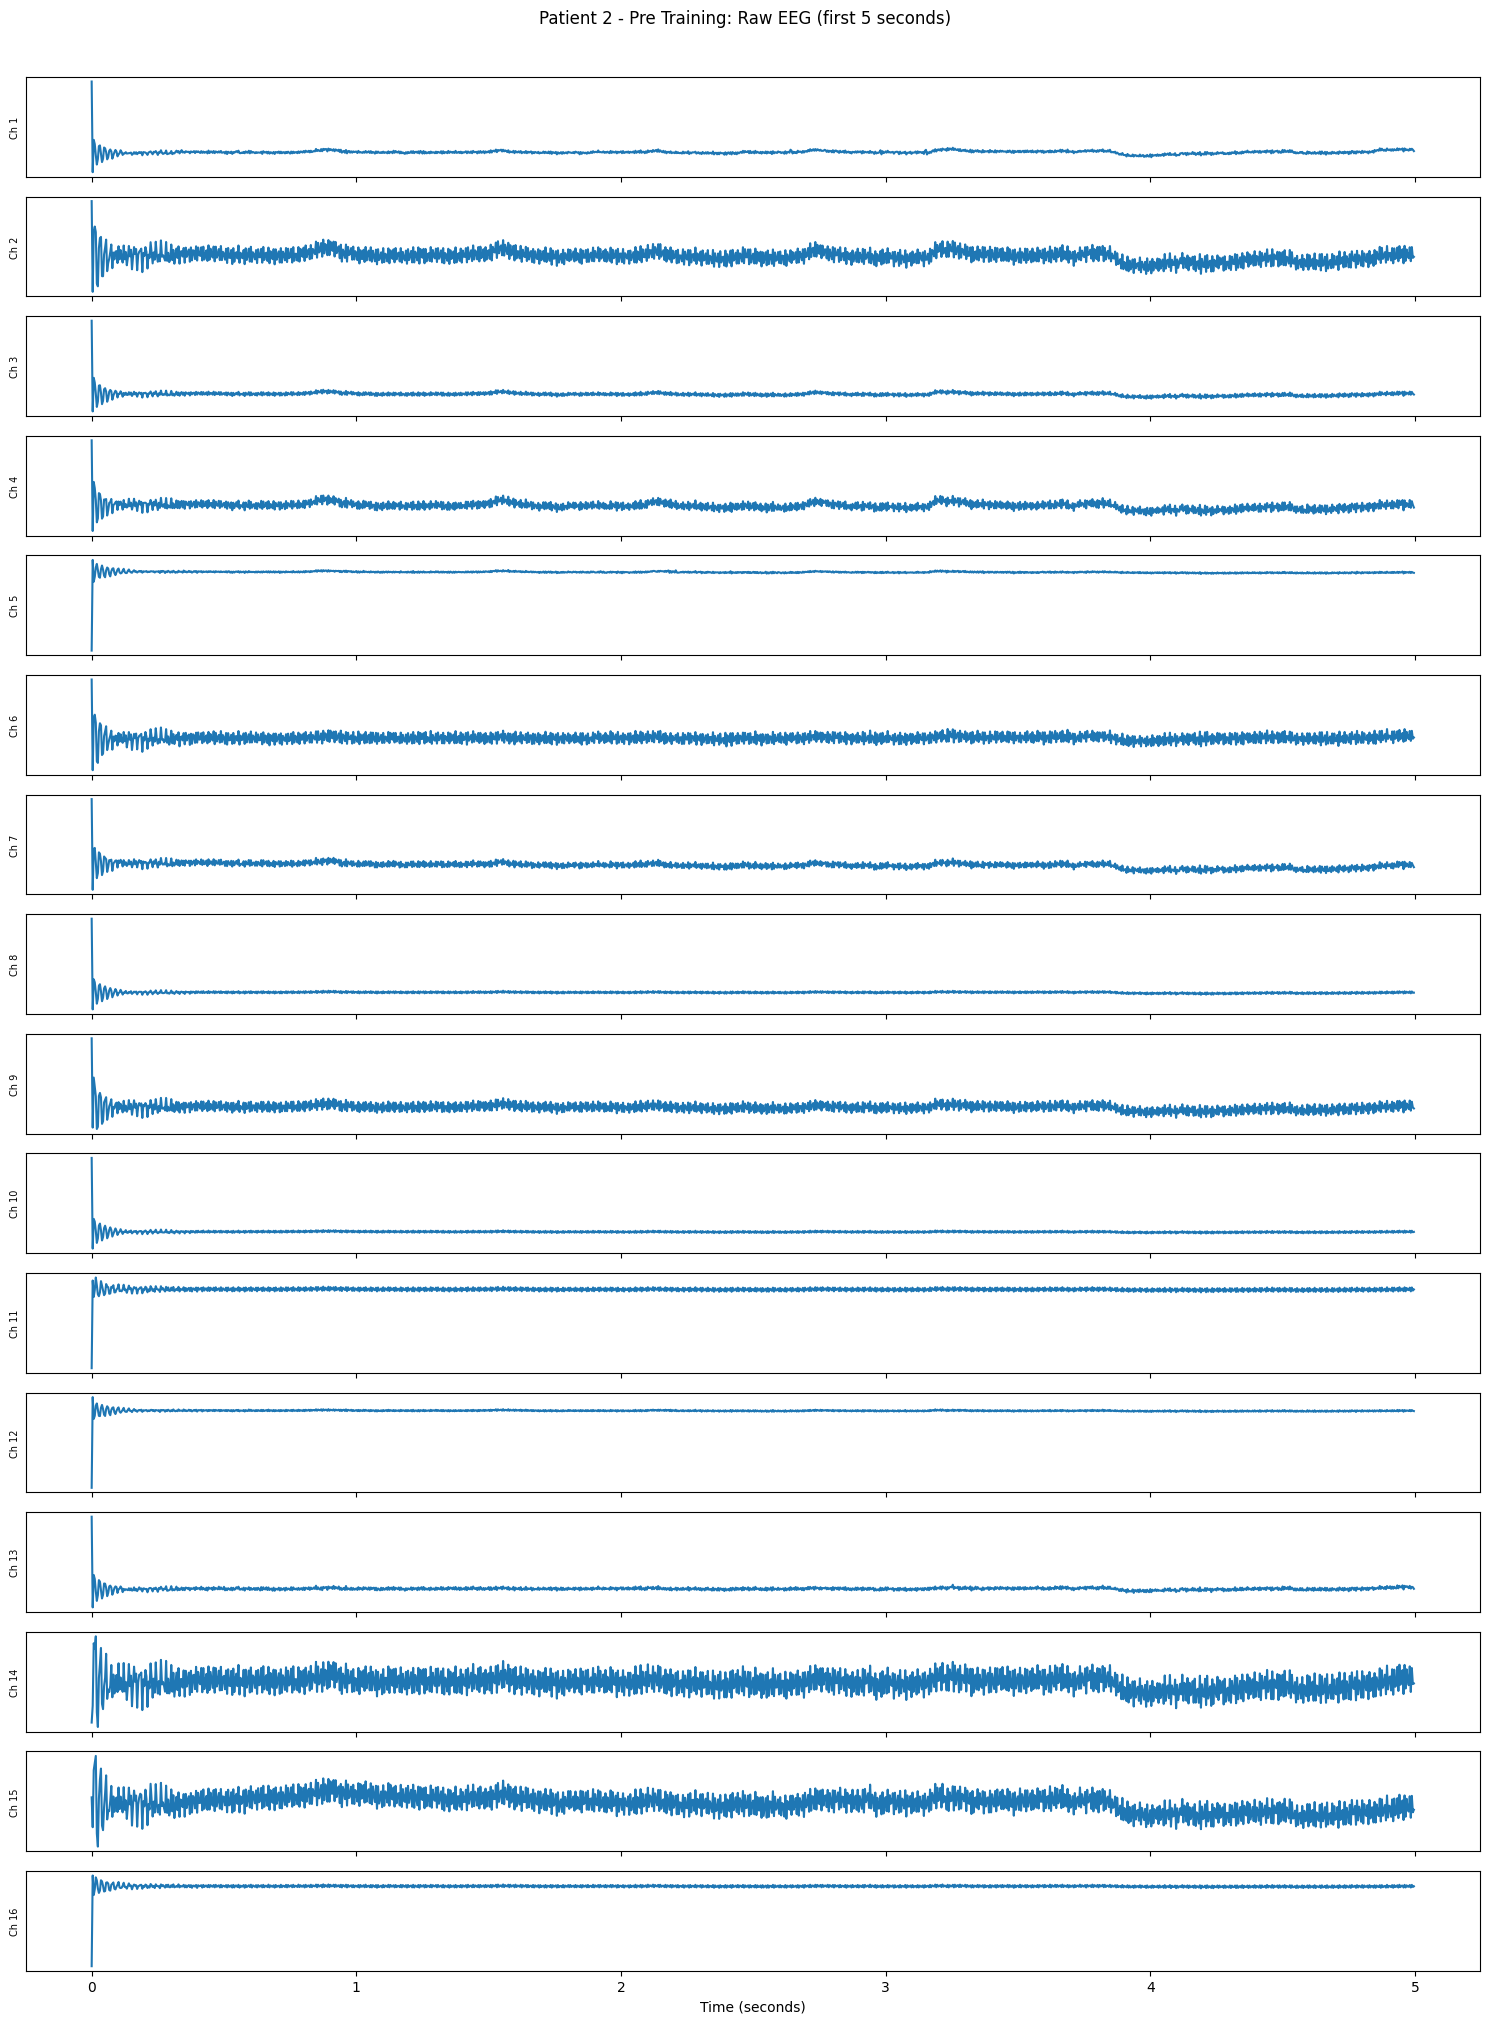

Plot saved!


In [5]:
# Fix the transpose issue
eeg_data = pre_train['y'].T  # Now shape is (16 channels, 223112 timepoints)
fs = int(pre_train['fs'][0][0])

print("Corrected shape:", eeg_data.shape)
print("Channels:", eeg_data.shape[0])
print("Duration (minutes):", round(eeg_data.shape[1] / fs / 60, 2))

# Plot first 5 seconds of raw EEG for all channels
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(eeg_data.shape[1]) / fs
fig, axes = plt.subplots(16, 1, figsize=(15, 20), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(time[:5*fs], eeg_data[i, :5*fs])
    ax.set_ylabel(f'Ch {i+1}', fontsize=7)
    ax.set_yticks([])

plt.xlabel('Time (seconds)')
plt.suptitle('Patient 2 - Pre Training: Raw EEG (first 5 seconds)', y=1.01)
plt.tight_layout()
plt.savefig('P2_raw_eeg.png')
plt.show()
print("Plot saved!")

In [6]:
from scipy.signal import butter, filtfilt

def bandpass_filter(data, lowcut=1, highcut=40, fs=256, order=4):
    nyq = fs / 2
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=1)

# Filter both pre and post training
eeg_pre = pre_train['y'].T
eeg_post = post_train['y'].T

eeg_pre_filtered = bandpass_filter(eeg_pre, fs=fs)
eeg_post_filtered = bandpass_filter(eeg_post, fs=fs)

print("Filtering complete!!!")
print("Pre training shape:", eeg_pre_filtered.shape)
print("Post training shape:", eeg_post_filtered.shape)

Filtering complete!!!
Pre training shape: (16, 223112)
Post training shape: (16, 216720)


In [8]:
from pathlib import Path
import numpy as np
import scipy.io as sio
import mne
import matplotlib.pyplot as plt

def adaptive_filter(raw, low=1.0, high=30.0):
    nyquist = raw.info['sfreq'] / 2
    h_freq = min(high, nyquist - 1)

    if h_freq <= low:
        raise ValueError(
            f"Invalid band: High cutoff ({h_freq}) <= ({low})."
            f" Nyquist = {nyquist}. Try using lower 'low' or higher sampling rate."
            )

    raw.notch_filter(freqs=[50, 60], picks='eeg', verbose=False)
    raw.filter(l_freq=low, h_freq=h_freq, picks='eeg')

    ica = ICA(n_components=0.95, random_state=42, max_iter=800)
    ica.fit(raw)
    fig = raw.plot(scalings='auto', show=False)
    fig.set_size_inches(15, 10)
    

    plt.show()
    ica.apply(raw)

    raw_cleaned = raw.copy()
    return raw_cleaned

#Run standalone
if __name__ == "__main__":
    import mne

    # Load your raw file from mat
    mat_path = Path("stroke-rehab\P2_pre_training.mat")
    mat = sio.loadmat(mat_path)
    eeg = mat["y"].astype(np.float64).T  # (channels, samples)
    trig = mat["trig"].flatten().astype(int)
    fs = int(mat["fs"][0, 0])
    CHANNEL_NAMES = ['FC3','FCz','FC4','C5','C3','C1','Cz','C2','C4','C6','CP3','CP1','CPz','CP2','CP4','Pz']
    info = mne.create_info(CHANNEL_NAMES, fs, ch_types="eeg")
    info.set_montage("standard_1020", on_missing="ignore")
    raw = mne.io.RawArray(eeg, info)

    # Run your cleaning pipeline
    cleaned = adaptive_filter(raw)

    # Save cleaned data back to mat
    sio.savemat(str(mat_path), {'y': cleaned.get_data().T, 'trig': trig, 'fs': fs})

    print("Preprocessing complete.")

# 1) Load.mat
mat_path = Path("stroke-rehab\P2_pre_training.mat")
mat = sio.loadmat(mat_path)
p1 = {
    "eeg": mat["y"].astype(np.float64),         # (samples, channels)
    "trig": mat["trig"].flatten().astype(int),  # señal de trigger nivelada
    "fs": int(mat["fs"][0, 0]),
}
print("p1 keys:", p1.keys())
print("eeg shape:", p1["eeg"].shape, "| trig shape:", p1["trig"].shape, "| fs:", p1["fs"])

# 2) Epochs 2 to 6 according to triggers
fs = p1["fs"]
t_start, t_end = 2.0, 6.0
n_start, n_end = int(t_start * fs), int(t_end * fs)
diff_trig = np.diff(p1["trig"], prepend=0)
onset_left = np.where(diff_trig == 1)[0]    # left
onset_right = np.where(diff_trig == -1)[0]  # right
epochs, labels = [], []
for onset in onset_left:
    s, e = onset + n_start, onset + n_end
    if s >= 0 and e <= len(p1["eeg"]):
        epochs.append(p1["eeg"][s:e, :].T)  # (channels, time)
        labels.append(1)  # left -> 1 para MNE event_id
for onset in onset_right:
    s, e = onset + n_start, onset + n_end
    if s >= 0 and e <= len(p1["eeg"]):
        epochs.append(p1["eeg"][s:e, :].T)
        labels.append(2)  # right -> 2
X = np.array(epochs)         # (n_epochs, n_channels, n_times)
y = np.array(labels, int)    # (n_epochs,)
print("X shape:", X.shape, "| y shape:", y.shape)

# 3) MNE EpochsArray
CHANNEL_NAMES = ['FC3','FCz','FC4','C5','C3','C1','Cz','C2','C4','C6','CP3','CP1','CPz','CP2','CP4','Pz']
info = mne.create_info(CHANNEL_NAMES, fs, ch_types="eeg")
info.set_montage("standard_1020", on_missing="ignore")
events = np.column_stack([
    np.arange(len(y), dtype=int),       # sample index del evento (artificial, válido para EpochsArray)
    np.zeros(len(y), dtype=int),
    y
])
p1_pre_mne = mne.EpochsArray(
    X, info, events=events,
    event_id={"left": 1, "right": 2},
    tmin=t_start,
    baseline=None,
    verbose=False,
)
print(p1_pre_mne)

# Visualization
p1_pre_mne.plot(scalings="auto")
plt.show()

Creating RawArray with float64 data, n_channels=16, n_times=223112
    Range : 0 ... 223111 =      0.000 ...   871.527 secs
Ready.


<>:37: SyntaxWarning: invalid escape sequence '\P'
<>:56: SyntaxWarning: invalid escape sequence '\P'
<>:37: SyntaxWarning: invalid escape sequence '\P'
<>:56: SyntaxWarning: invalid escape sequence '\P'
C:\Users\ranit\AppData\Local\Temp\ipykernel_10560\4292190910.py:37: SyntaxWarning: invalid escape sequence '\P'
  mat_path = Path("stroke-rehab\P2_pre_training.mat")
C:\Users\ranit\AppData\Local\Temp\ipykernel_10560\4292190910.py:56: SyntaxWarning: invalid escape sequence '\P'
  mat_path = Path("stroke-rehab\P2_pre_training.mat")


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 845 samples (3.301 s)



NameError: name 'ICA' is not defined

In [12]:
from pathlib import Path
import scipy.io as sio
import numpy as np

# ── Paths ──
TRAIN_DIR = Path("stroke-rehab")
TEST_DIR  = Path("stroke-rehab")

# ── Simple data container ──
class RunData:
    def __init__(self, eeg, trig, fs):
        self.eeg  = eeg
        self.trig = trig
        self.fs   = fs

# ── Loaders ──
def load_run_mat(path: Path) -> RunData:
    mat = sio.loadmat(path)
    eeg  = mat["y"].astype(np.float64)
    trig = mat["trig"].flatten().astype(int)
    fs   = int(mat["fs"][0, 0])
    return RunData(eeg, trig, fs)

def extract_trigger_onsets(trig: np.ndarray, direction: int) -> np.ndarray:
    diff = np.diff(trig, prepend=0)
    return np.where(diff == direction)[0]

In [15]:
from pathlib import Path
import scipy.io as sio
import numpy as np

# ── Paths ──
TRAIN_DIR = Path("stroke-rehab")
TEST_DIR  = Path("stroke-rehab")

# ── Simple data container ──
class RunData:
    def __init__(self, eeg, trig, fs):
        self.eeg  = eeg
        self.trig = trig
        self.fs   = fs

# ── Loaders ──
def load_run_mat(path: Path) -> RunData:
    mat = sio.loadmat(path)
    eeg  = mat["y"].astype(np.float64)
    trig = mat["trig"].flatten().astype(int)
    fs   = int(mat["fs"][0, 0])
    return RunData(eeg, trig, fs)

def extract_trigger_onsets(trig: np.ndarray, direction: int) -> np.ndarray:
    diff = np.diff(trig, prepend=0)
    return np.where(diff == direction)[0]

Creating RawArray with float64 data, n_channels=16, n_times=223112
    Range : 0 ... 223111 =      0.000 ...   871.527 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 845 samples (3.301 s)

Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by explained variance: 2 components
Fitting ICA took 0.4s.


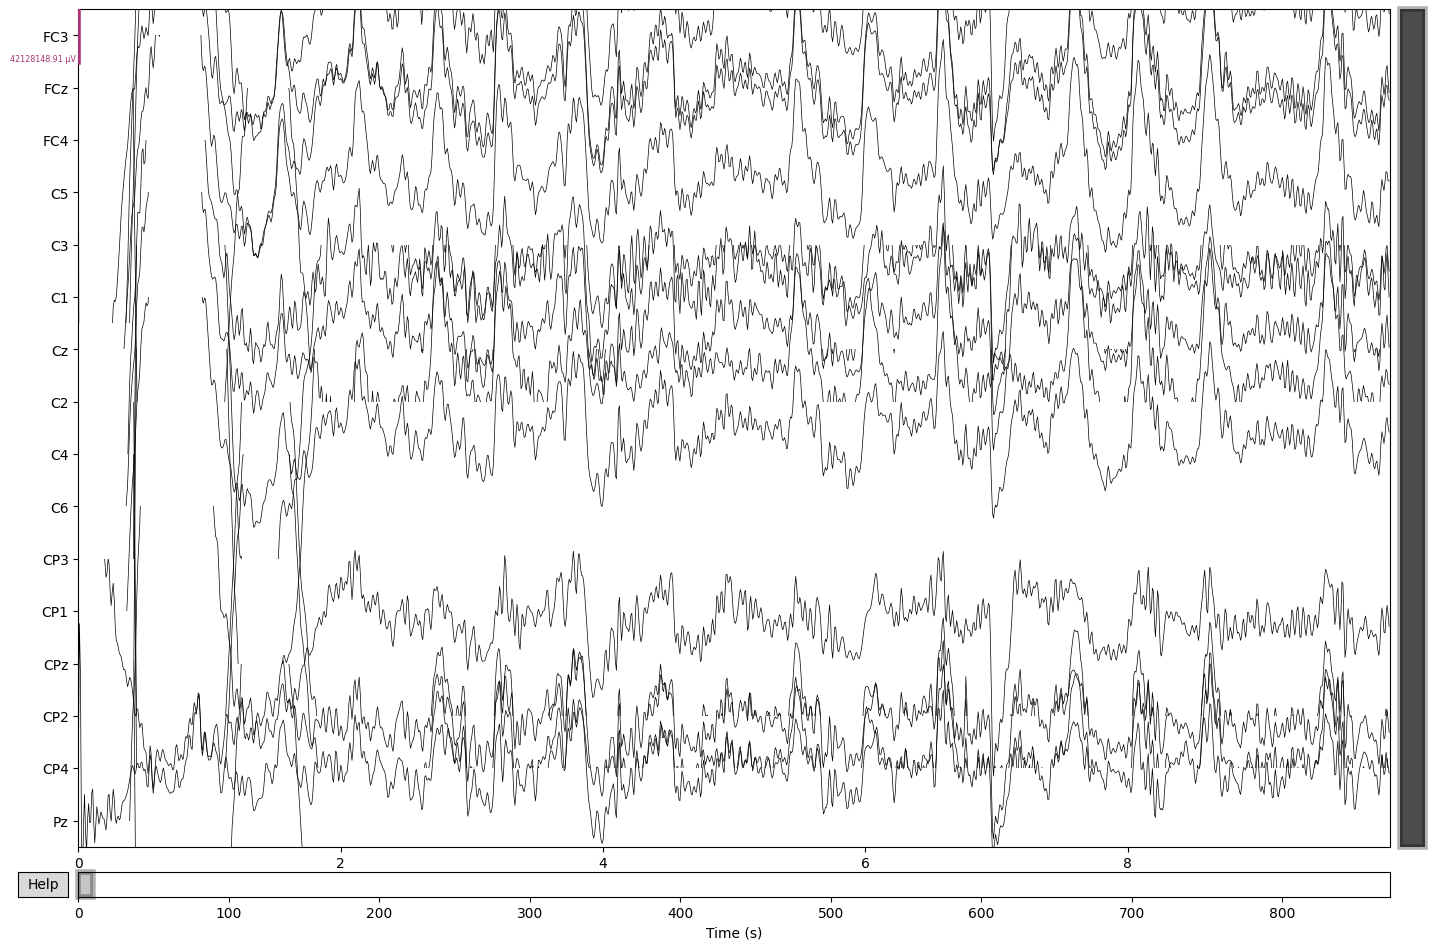

Applying ICA to Raw instance
    Transforming to ICA space (2 components)
    Zeroing out 0 ICA components
    Projecting back using 16 PCA components
Preprocessing complete.
p1 keys: dict_keys(['eeg', 'trig', 'fs'])
eeg shape: (223112, 16) | trig shape: (223112,) | fs: 256
X shape: (159, 16, 1024) | y shape: (159,)
<EpochsArray | 159 events (all good), 2 – 5.996 s (baseline off), ~19.9 MiB, data loaded,
 'left': 80
 'right': 79>


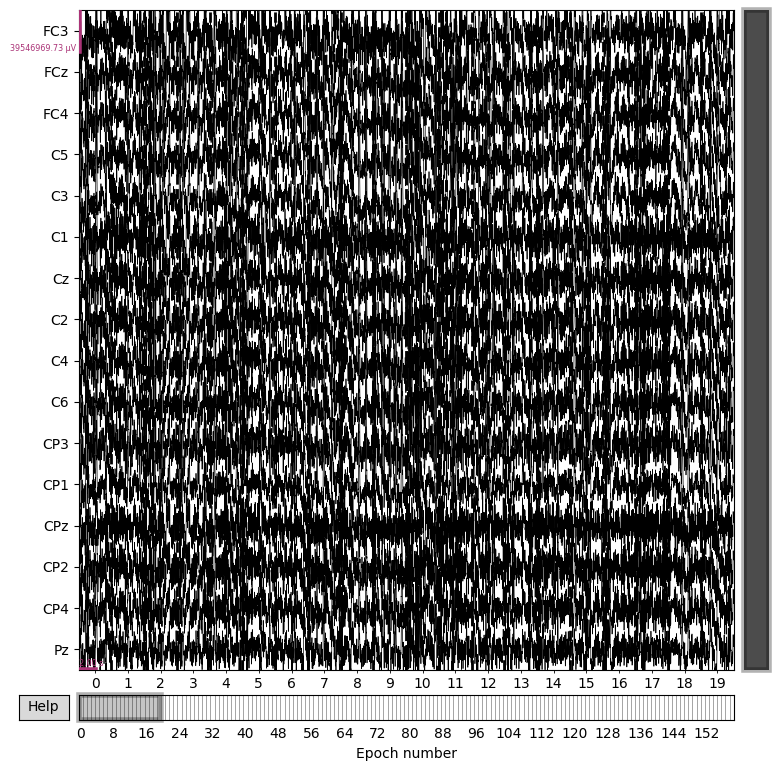

In [16]:
from pathlib import Path
import numpy as np
import scipy.io as sio
import mne
import matplotlib.pyplot as plt
from mne.preprocessing import ICA

def adaptive_filter(raw, low=1.0, high=30.0):
    nyquist = raw.info['sfreq'] / 2
    h_freq = min(high, nyquist - 1)

    if h_freq <= low:
        raise ValueError(
            f"Invalid band: High cutoff ({h_freq}) <= ({low})."
            f" Nyquist = {nyquist}. Try using lower 'low' or higher sampling rate."
            )

    raw.notch_filter(freqs=[50, 60], picks='eeg', verbose=False)
    raw.filter(l_freq=low, h_freq=h_freq, picks='eeg')

    ica = ICA(n_components=0.95, random_state=42, max_iter=800)
    ica.fit(raw)
    fig = raw.plot(scalings='auto', show=False)
    fig.set_size_inches(15, 10)
    

    plt.show()
    ica.apply(raw)

    raw_cleaned = raw.copy()
    return raw_cleaned

#Run standalone
if __name__ == "__main__":
    import mne

    # Load your raw file from mat
    mat_path = Path("stroke-rehab/P2_pre_training.mat")
    mat = sio.loadmat(mat_path)
    eeg = mat["y"].astype(np.float64).T  # (channels, samples)
    trig = mat["trig"].flatten().astype(int)
    fs = int(mat["fs"][0, 0])
    CHANNEL_NAMES = ['FC3','FCz','FC4','C5','C3','C1','Cz','C2','C4','C6','CP3','CP1','CPz','CP2','CP4','Pz']
    info = mne.create_info(CHANNEL_NAMES, fs, ch_types="eeg")
    info.set_montage("standard_1020", on_missing="ignore")
    raw = mne.io.RawArray(eeg, info)

    # Run your cleaning pipeline
    cleaned = adaptive_filter(raw)

    # Save cleaned data back to mat
    sio.savemat(str(mat_path), {'y': cleaned.get_data().T, 'trig': trig, 'fs': fs})

    print("Preprocessing complete.")

# 1) Load.mat
mat_path = Path("stroke-rehab/P2_pre_training.mat")
mat = sio.loadmat(mat_path)
p1 = {
    "eeg": mat["y"].astype(np.float64),         # (samples, channels)
    "trig": mat["trig"].flatten().astype(int),  # señal de trigger nivelada
    "fs": int(mat["fs"][0, 0]),
}
print("p1 keys:", p1.keys())
print("eeg shape:", p1["eeg"].shape, "| trig shape:", p1["trig"].shape, "| fs:", p1["fs"])

# 2) Epochs 2 to 6 according to triggers
fs = p1["fs"]
t_start, t_end = 2.0, 6.0
n_start, n_end = int(t_start * fs), int(t_end * fs)
diff_trig = np.diff(p1["trig"], prepend=0)
onset_left = np.where(diff_trig == 1)[0]    # left
onset_right = np.where(diff_trig == -1)[0]  # right
epochs, labels = [], []
for onset in onset_left:
    s, e = onset + n_start, onset + n_end
    if s >= 0 and e <= len(p1["eeg"]):
        epochs.append(p1["eeg"][s:e, :].T)  # (channels, time)
        labels.append(1)  # left -> 1 para MNE event_id
for onset in onset_right:
    s, e = onset + n_start, onset + n_end
    if s >= 0 and e <= len(p1["eeg"]):
        epochs.append(p1["eeg"][s:e, :].T)
        labels.append(2)  # right -> 2
X = np.array(epochs)         # (n_epochs, n_channels, n_times)
y = np.array(labels, int)    # (n_epochs,)
print("X shape:", X.shape, "| y shape:", y.shape)

# 3) MNE EpochsArray
CHANNEL_NAMES = ['FC3','FCz','FC4','C5','C3','C1','Cz','C2','C4','C6','CP3','CP1','CPz','CP2','CP4','Pz']
info = mne.create_info(CHANNEL_NAMES, fs, ch_types="eeg")
info.set_montage("standard_1020", on_missing="ignore")
events = np.column_stack([
    np.arange(len(y), dtype=int),       # sample index del evento (artificial, válido para EpochsArray)
    np.zeros(len(y), dtype=int),
    y
])
p1_pre_mne = mne.EpochsArray(
    X, info, events=events,
    event_id={"left": 1, "right": 2},
    tmin=t_start,
    baseline=None,
    verbose=False,
)
print(p1_pre_mne)

# Visualization
p1_pre_mne.plot(scalings="auto")
plt.show() # pyright: ignore[reportUndefinedVariable]

C:\Users\ranit\AppData\Local\Temp\ipykernel_10560\580151692.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([left_C3_power, right_C3_power],
C:\Users\ranit\AppData\Local\Temp\ipykernel_10560\580151692.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([left_C4_power, right_C4_power],


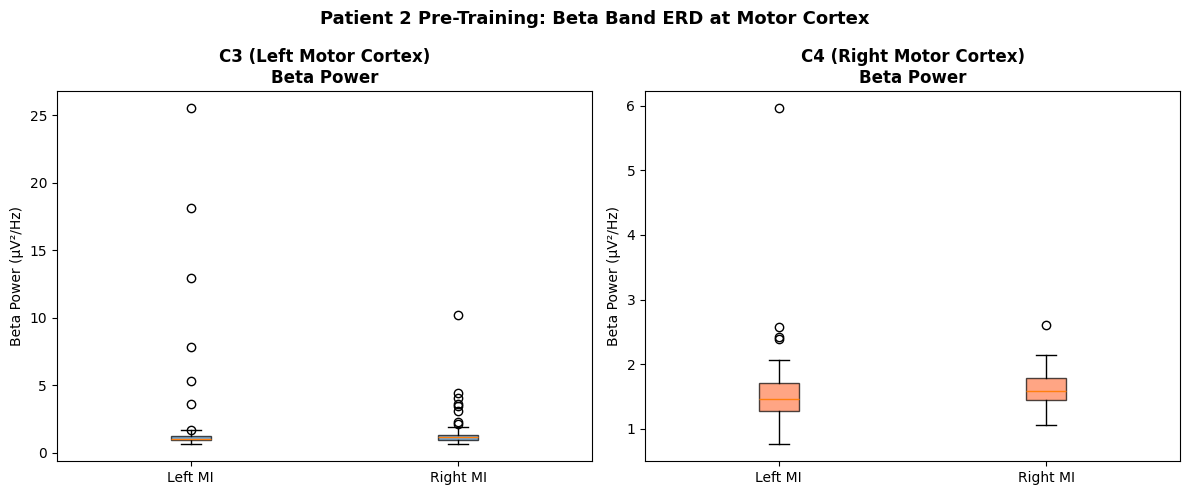

C3 - Left MI beta power: 1.8913
C3 - Right MI beta power: 1.4434
C4 - Left MI beta power: 1.5444
C4 - Right MI beta power: 1.6150


In [11]:
# Event Related Desynchronisation (ERD) on C3 and C4
# ERD = decrease in alpha/beta power during motor imagery
# This is the KEY stroke recovery signal

# Get epochs data
left_epochs = p1_pre_mne['left'].get_data()   # (80, 16, 1024)
right_epochs = p1_pre_mne['right'].get_data() # (79, 16, 1024)

# Channel indices
# ['FC3','FCz','FC4','C5','C3','C1','Cz','C2','C4','C6',...]
#                          [4]              [8]
C3_idx = 4
C4_idx = 8

# Calculate power in beta band (13-30 Hz) for C3 and C4
from scipy.signal import welch

def band_power(data, fs=256, low=13, high=30):
    freqs, psd = welch(data, fs=fs, nperseg=256)
    idx = np.where((freqs >= low) & (freqs <= high))
    return np.mean(psd[idx])

# Left trials - beta power at C3 and C4
left_C3_power = [band_power(trial[C3_idx]) for trial in left_epochs]
left_C4_power = [band_power(trial[C4_idx]) for trial in left_epochs]

# Right trials - beta power at C3 and C4
right_C3_power = [band_power(trial[C3_idx]) for trial in right_epochs]
right_C4_power = [band_power(trial[C4_idx]) for trial in right_epochs]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# C3
axes[0].boxplot([left_C3_power, right_C3_power], 
                labels=['Left MI', 'Right MI'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0].set_title('C3 (Left Motor Cortex)\nBeta Power', fontweight='bold')
axes[0].set_ylabel('Beta Power (µV²/Hz)')

# C4
axes[1].boxplot([left_C4_power, right_C4_power],
                labels=['Left MI', 'Right MI'],
                patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.7))
axes[1].set_title('C4 (Right Motor Cortex)\nBeta Power', fontweight='bold')
axes[1].set_ylabel('Beta Power (µV²/Hz)')

plt.suptitle('Patient 2 Pre-Training: Beta Band ERD at Motor Cortex', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('P2_ERD_C3_C4.png')
plt.show()

# Print summary
print(f"C3 - Left MI beta power: {np.mean(left_C3_power):.4f}")
print(f"C3 - Right MI beta power: {np.mean(right_C3_power):.4f}")
print(f"C4 - Left MI beta power: {np.mean(left_C4_power):.4f}")
print(f"C4 - Right MI beta power: {np.mean(right_C4_power):.4f}")

In [17]:
from pathlib import Path
import scipy.io as sio
import numpy as np

# ── Paths ──
TRAIN_DIR = Path("stroke-rehab")
TEST_DIR  = Path("stroke-rehab")

# ── Simple data container ──
class RunData:
    def __init__(self, eeg, trig, fs):
        self.eeg  = eeg
        self.trig = trig
        self.fs   = fs

# ── Loaders ──
def load_run_mat(path: Path) -> RunData:
    mat = sio.loadmat(path)
    eeg  = mat["y"].astype(np.float64)
    trig = mat["trig"].flatten().astype(int)
    fs   = int(mat["fs"][0, 0])
    return RunData(eeg, trig, fs)

def extract_trigger_onsets(trig: np.ndarray, direction: int) -> np.ndarray:
    diff = np.diff(trig, prepend=0)
    return np.where(diff == direction)[0]

Creating RawArray with float64 data, n_channels=16, n_times=223112
    Range : 0 ... 223111 =      0.000 ...   871.527 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 845 samples (3.301 s)

Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by explained variance: 2 components
Fitting ICA took 0.4s.


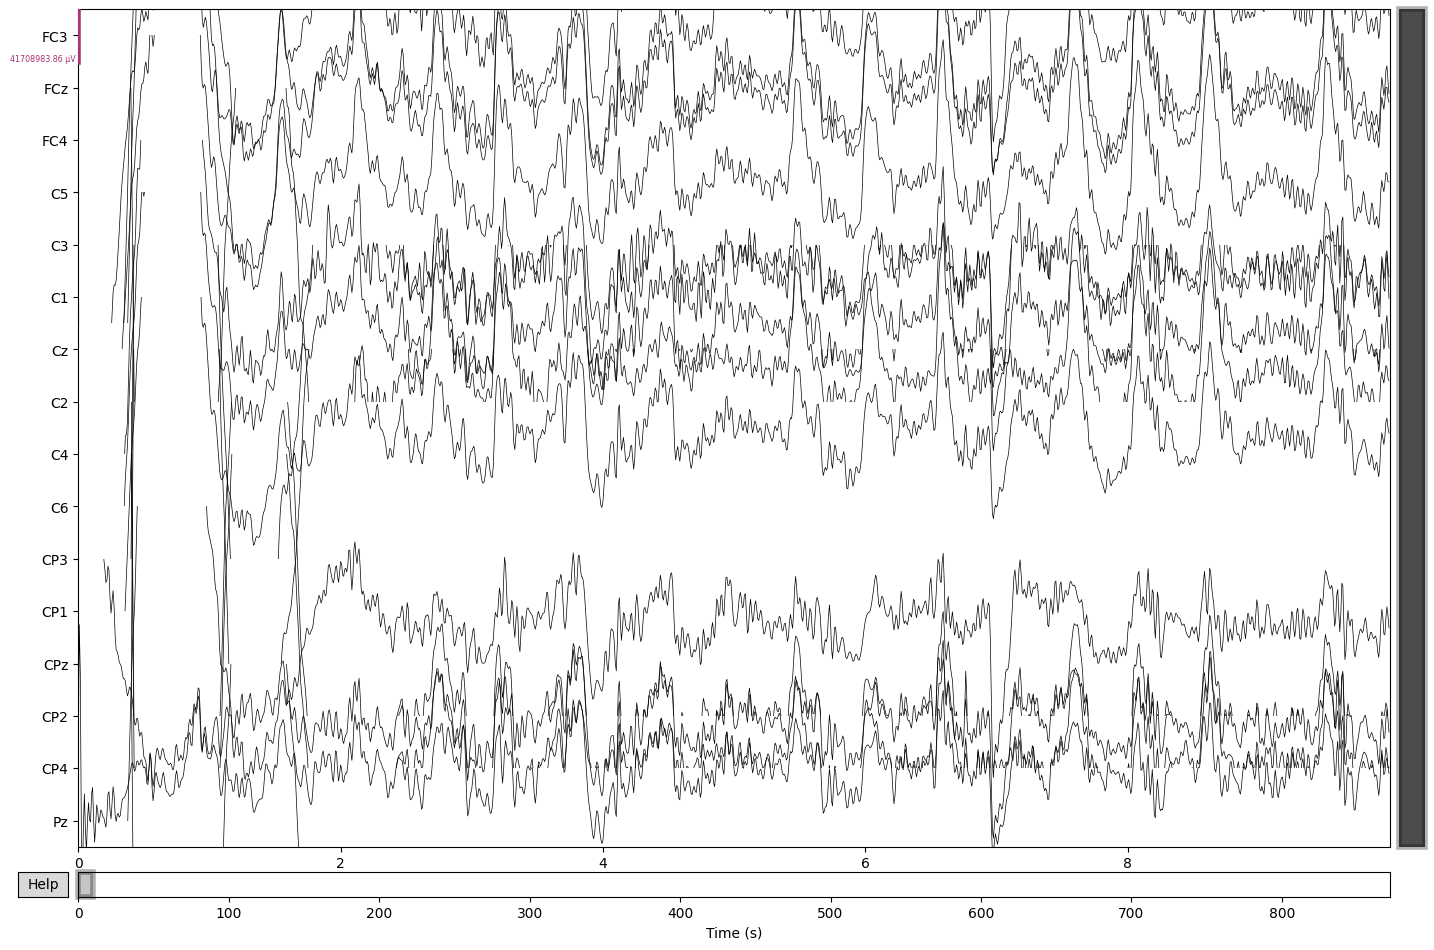

Applying ICA to Raw instance
    Transforming to ICA space (2 components)
    Zeroing out 0 ICA components
    Projecting back using 16 PCA components
Preprocessing complete.
p1 keys: dict_keys(['eeg', 'trig', 'fs'])
eeg shape: (223112, 16) | trig shape: (223112,) | fs: 256
X shape: (159, 16, 1024) | y shape: (159,)
<EpochsArray | 159 events (all good), 2 – 5.996 s (baseline off), ~19.9 MiB, data loaded,
 'left': 80
 'right': 79>


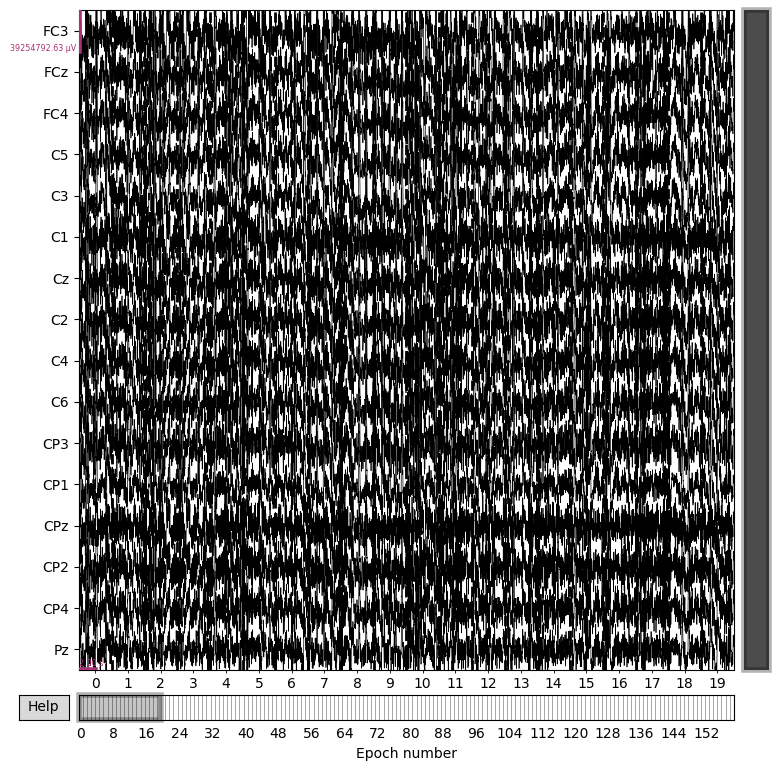

In [18]:
from pathlib import Path
import numpy as np
import scipy.io as sio
import mne
import matplotlib.pyplot as plt
from mne.preprocessing import ICA

def adaptive_filter(raw, low=1.0, high=30.0):
    nyquist = raw.info['sfreq'] / 2
    h_freq = min(high, nyquist - 1)

    if h_freq <= low:
        raise ValueError(
            f"Invalid band: High cutoff ({h_freq}) <= ({low})."
            f" Nyquist = {nyquist}. Try using lower 'low' or higher sampling rate."
            )

    raw.notch_filter(freqs=[50, 60], picks='eeg', verbose=False)
    raw.filter(l_freq=low, h_freq=h_freq, picks='eeg')

    ica = ICA(n_components=0.95, random_state=42, max_iter=800)
    ica.fit(raw)
    fig = raw.plot(scalings='auto', show=False)
    fig.set_size_inches(15, 10)
    

    plt.show()
    ica.apply(raw)

    raw_cleaned = raw.copy()
    return raw_cleaned

#Run standalone
if __name__ == "__main__":
    import mne

    # Load your raw file from mat
    mat_path = Path("stroke-rehab/P2_pre_training.mat")
    mat = sio.loadmat(mat_path)
    eeg = mat["y"].astype(np.float64).T  # (channels, samples)
    trig = mat["trig"].flatten().astype(int)
    fs = int(mat["fs"][0, 0])
    CHANNEL_NAMES = ['FC3','FCz','FC4','C5','C3','C1','Cz','C2','C4','C6','CP3','CP1','CPz','CP2','CP4','Pz']
    info = mne.create_info(CHANNEL_NAMES, fs, ch_types="eeg")
    info.set_montage("standard_1020", on_missing="ignore")
    raw = mne.io.RawArray(eeg, info)

    # Run your cleaning pipeline
    cleaned = adaptive_filter(raw)

    # Save cleaned data back to mat
    sio.savemat(str(mat_path), {'y': cleaned.get_data().T, 'trig': trig, 'fs': fs})

    print("Preprocessing complete.")

# 1) Load.mat
mat_path = Path("stroke-rehab/P2_pre_training.mat")
mat = sio.loadmat(mat_path)
p1 = {
    "eeg": mat["y"].astype(np.float64),         # (samples, channels)
    "trig": mat["trig"].flatten().astype(int),  # señal de trigger nivelada
    "fs": int(mat["fs"][0, 0]),
}
print("p1 keys:", p1.keys())
print("eeg shape:", p1["eeg"].shape, "| trig shape:", p1["trig"].shape, "| fs:", p1["fs"])

# 2) Epochs 2 to 6 according to triggers
fs = p1["fs"]
t_start, t_end = 2.0, 6.0
n_start, n_end = int(t_start * fs), int(t_end * fs)
diff_trig = np.diff(p1["trig"], prepend=0)
onset_left = np.where(diff_trig == 1)[0]    # left
onset_right = np.where(diff_trig == -1)[0]  # right
epochs, labels = [], []
for onset in onset_left:
    s, e = onset + n_start, onset + n_end
    if s >= 0 and e <= len(p1["eeg"]):
        epochs.append(p1["eeg"][s:e, :].T)  # (channels, time)
        labels.append(1)  # left -> 1 para MNE event_id
for onset in onset_right:
    s, e = onset + n_start, onset + n_end
    if s >= 0 and e <= len(p1["eeg"]):
        epochs.append(p1["eeg"][s:e, :].T)
        labels.append(2)  # right -> 2
X = np.array(epochs)         # (n_epochs, n_channels, n_times)
y = np.array(labels, int)    # (n_epochs,)
print("X shape:", X.shape, "| y shape:", y.shape)

# 3) MNE EpochsArray
CHANNEL_NAMES = ['FC3','FCz','FC4','C5','C3','C1','Cz','C2','C4','C6','CP3','CP1','CPz','CP2','CP4','Pz']
info = mne.create_info(CHANNEL_NAMES, fs, ch_types="eeg")
info.set_montage("standard_1020", on_missing="ignore")
events = np.column_stack([
    np.arange(len(y), dtype=int),       # sample index del evento (artificial, válido para EpochsArray)
    np.zeros(len(y), dtype=int),
    y
])
p1_pre_mne = mne.EpochsArray(
    X, info, events=events,
    event_id={"left": 1, "right": 2},
    tmin=t_start,
    baseline=None,
    verbose=False,
)
print(p1_pre_mne)

# Visualization
p1_pre_mne.plot(scalings="auto")
plt.show() # pyright: ignore[reportUndefinedVariable]

In [19]:
from pathlib import Path
import scipy.io as sio
import numpy as np

# ── Paths ──
TRAIN_DIR = Path("stroke-rehab")
TEST_DIR  = Path("stroke-rehab")

# ── Simple data container ──
class RunData:
    def __init__(self, eeg, trig, fs):
        self.eeg  = eeg
        self.trig = trig
        self.fs   = fs

# ── Loaders ──
def load_run_mat(path: Path) -> RunData:
    mat = sio.loadmat(path)
    eeg  = mat["y"].astype(np.float64)
    trig = mat["trig"].flatten().astype(int)
    fs   = int(mat["fs"][0, 0])
    return RunData(eeg, trig, fs)

def extract_trigger_onsets(trig: np.ndarray, direction: int) -> np.ndarray:
    diff = np.diff(trig, prepend=0)
    return np.where(diff == direction)[0]

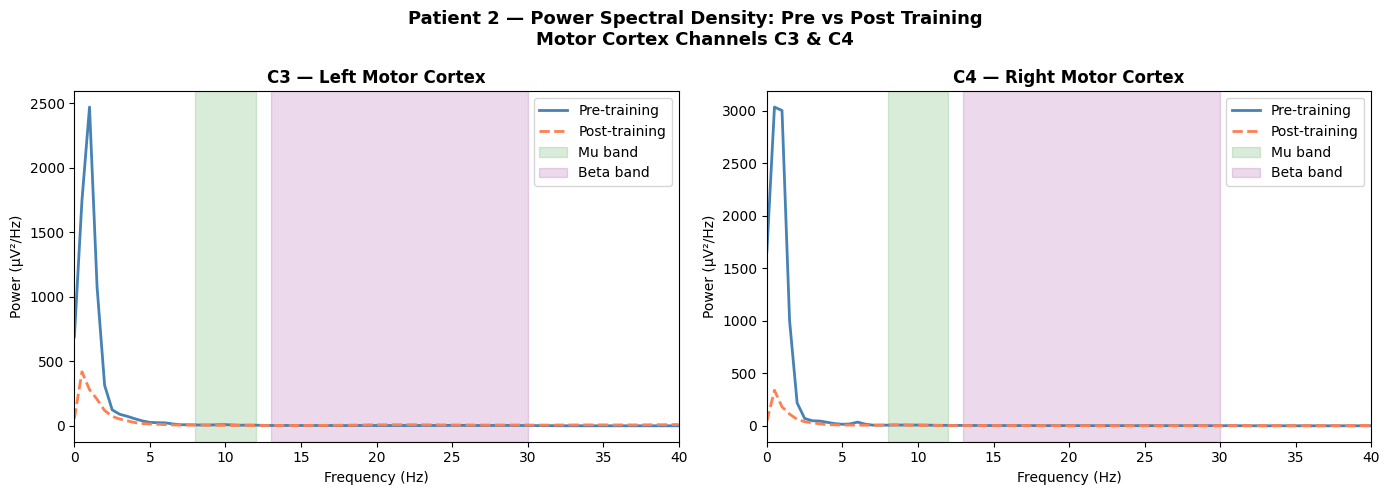

Done!


In [22]:
# Power Spectral Density - Pre vs Post Training
# Shows which frequencies are most active in Patient 2's brain

import scipy.signal as signal

CHANNEL_NAMES_16 = ['FC3','FCz','FC4','C5','C3','C1','Cz','C2','C4','C6',
                     'CP3','CP1','CPz','CP2','CP4','Pz']

# Load both sessions
pre  = load_run_mat(Path("stroke-rehab/P2_pre_training.mat"))
post = load_run_mat(Path("stroke-rehab/P2_post_training.mat"))

# Focus on C3 (index 4) and C4 (index 9) — motor cortex
C3_idx = 4
C4_idx = 9

# Calculate PSD for each
freqs_pre,  psd_pre_C3  = signal.welch(pre.eeg[:,  C3_idx], fs=pre.fs,  nperseg=512)
freqs_post, psd_post_C3 = signal.welch(post.eeg[:, C3_idx], fs=post.fs, nperseg=512)
freqs_pre,  psd_pre_C4  = signal.welch(pre.eeg[:,  C4_idx], fs=pre.fs,  nperseg=512)
freqs_post, psd_post_C4 = signal.welch(post.eeg[:, C4_idx], fs=post.fs, nperseg=512)

# Plot only 0-40 Hz (brain frequencies)
freq_mask = freqs_pre <= 40

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# C3
ax1.plot(freqs_pre[freq_mask],  psd_pre_C3[freq_mask],
         label='Pre-training',  color='steelblue', linewidth=2)
ax1.plot(freqs_post[freq_mask], psd_post_C3[freq_mask],
         label='Post-training', color='coral', linewidth=2, linestyle='--')
ax1.axvspan(8,  12, alpha=0.15, color='green',  label='Mu band')
ax1.axvspan(13, 30, alpha=0.15, color='purple', label='Beta band')
ax1.set_title('C3 — Left Motor Cortex', fontweight='bold', fontsize=12)
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Power (µV²/Hz)')
ax1.legend()
ax1.set_xlim(0, 40)

# C4
ax2.plot(freqs_pre[freq_mask],  psd_pre_C4[freq_mask],
         label='Pre-training',  color='steelblue', linewidth=2)
ax2.plot(freqs_post[freq_mask], psd_post_C4[freq_mask],
         label='Post-training', color='coral', linewidth=2, linestyle='--')
ax2.axvspan(8,  12, alpha=0.15, color='green',  label='Mu band')
ax2.axvspan(13, 30, alpha=0.15, color='purple', label='Beta band')
ax2.set_title('C4 — Right Motor Cortex', fontweight='bold', fontsize=12)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Power (µV²/Hz)')
ax2.legend()
ax2.set_xlim(0, 40)

fig.suptitle('Patient 2 — Power Spectral Density: Pre vs Post Training\n'
             'Motor Cortex Channels C3 & C4',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('P2_PSD_C3_C4.png', dpi=300, bbox_inches='tight')
plt.show()
print("Done!")

C:\Users\ranit\AppData\Local\Temp\ipykernel_10560\1358072487.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


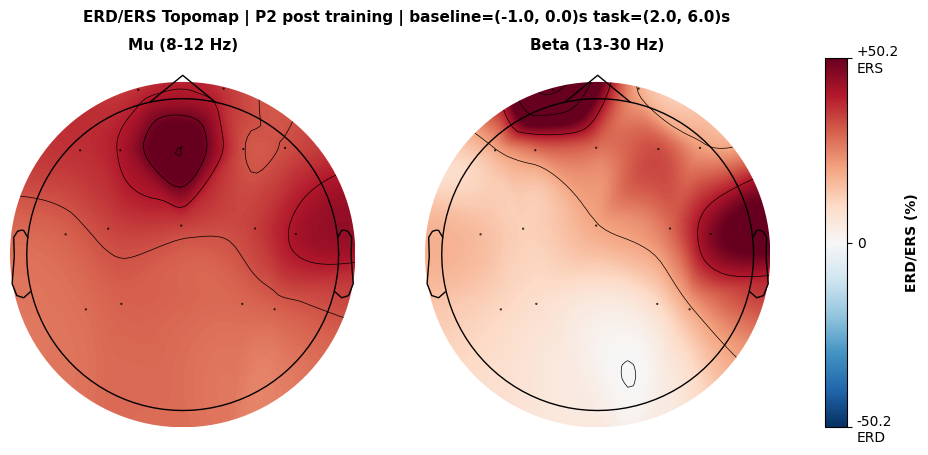

In [21]:
# ===================== ERD/ERS TOPO MAP (from scratch) =====================
# This cell computes ERD/ERS (%) and plots topomaps for Mu and Beta bands.
# Formula: ERD/ERS = (Power_task - Power_baseline) / Power_baseline * 100

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import mne
from matplotlib.colors import Normalize

# ---------- Config ----------
TOPOMAP_PATIENT = 'P2'
TOPOMAP_SESSION = 'post'      # 'pre' or 'post'
TOPOMAP_RUN = 'training'     # 'training' or 'test'

BASELINE_WIN = (-1.0, 0.0)   # seconds relative to trigger
TASK_WIN = (2.0, 6.0)        # seconds relative to trigger

BANDS = {
    'Mu (8-12 Hz)': (8.0, 12.0),
    'Beta (13-30 Hz)': (13.0, 30.0),
}

# IMPORTANT:
# Your data has 16 channels. Replace these names with your true cap order if needed.
DEFAULT_CH_NAMES_16 = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7',
    'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'P4', 'P8'
]

# Optional old->new name mapping for montage compatibility
CH_MNE_MAP = {'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'}

# ---------- Helpers ----------
def get_run_data(patient: str, session: str, run_kind: str):
    if run_kind == 'training':
        path = TRAIN_DIR / f'{patient}_{session}_training.mat'
    else:
        path = TEST_DIR / f'{patient}_{session}_test.mat'
    return load_run_mat(path)


def get_trigger_onsets(trig: np.ndarray):
    left_onsets = extract_trigger_onsets(trig, +1)
    right_onsets = extract_trigger_onsets(trig, -1)
    all_onsets = np.sort(np.concatenate([left_onsets, right_onsets]))
    return all_onsets


def slice_window(eeg: np.ndarray, onset: int, fs: int, win_s: tuple[float, float]):
    s = onset + int(round(win_s[0] * fs))
    e = onset + int(round(win_s[1] * fs))
    if s < 0 or e > eeg.shape[0] or e <= s:
        return None
    # output shape: (channels, samples)
    return eeg[s:e, :].T


def band_power_trials(trials_chn_time: np.ndarray, fs: float, f_lo: float, f_hi: float):
    # trials_chn_time: (n_trials, n_channels, n_samples)
    nperseg = min(256, trials_chn_time.shape[-1])
    freqs, psd = signal.welch(trials_chn_time, fs=fs, nperseg=nperseg, axis=-1)
    mask = (freqs >= f_lo) & (freqs <= f_hi)
    if not np.any(mask):
        raise ValueError(f'No PSD bins found in [{f_lo}, {f_hi}] Hz')
    # return per-trial per-channel mean band power
    return psd[:, :, mask].mean(axis=-1)


# ---------- Load and build baseline/task epochs ----------
run = get_run_data(TOPOMAP_PATIENT, TOPOMAP_SESSION, TOPOMAP_RUN)
fs = int(run.fs)
all_onsets = get_trigger_onsets(run.trig)

baseline_epochs = []
task_epochs = []
for onset in all_onsets:
    b = slice_window(run.eeg, onset, fs, BASELINE_WIN)
    t = slice_window(run.eeg, onset, fs, TASK_WIN)
    if b is not None and t is not None:
        baseline_epochs.append(b)
        task_epochs.append(t)

if len(baseline_epochs) == 0 or len(task_epochs) == 0:
    raise RuntimeError('No valid baseline/task epochs. Adjust windows or inspect triggers.')

X_base = np.asarray(baseline_epochs, dtype=np.float64)   # (trials, ch, time)
X_task = np.asarray(task_epochs, dtype=np.float64)       # (trials, ch, time)

n_ch = X_task.shape[1]
if n_ch != 16:
    print(f'Warning: expected 16 channels, found {n_ch}. Update channel names accordingly.')
ch_names = DEFAULT_CH_NAMES_16[:n_ch]
ch_names_mne = [CH_MNE_MAP.get(ch, ch) for ch in ch_names]

info = mne.create_info(ch_names=ch_names_mne, sfreq=float(fs), ch_types=['eeg'] * n_ch)
info.set_montage(mne.channels.make_standard_montage('standard_1020'), on_missing='warn')

# ---------- Compute ERD/ERS per band ----------
erd_ers_maps = {}
for band_name, (f_lo, f_hi) in BANDS.items():
    p_base = band_power_trials(X_base, fs=float(fs), f_lo=f_lo, f_hi=f_hi)  # (trials, ch)
    p_task = band_power_trials(X_task, fs=float(fs), f_lo=f_lo, f_hi=f_hi)  # (trials, ch)

    # average across trials first, then ERD/ERS formula per channel
    mean_base = p_base.mean(axis=0)
    mean_task = p_task.mean(axis=0)
    erd_ers = (mean_task - mean_base) / (mean_base + 1e-12) * 100.0
    erd_ers_maps[band_name] = erd_ers

# ---------- Plot topomaps ----------
all_vals = np.concatenate(list(erd_ers_maps.values()))
vlim = max(10.0, float(np.percentile(np.abs(all_vals), 95)))

fig = plt.figure(figsize=(11, 4.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.06], wspace=0.15)
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
cax = fig.add_subplot(gs[0, 2])

for ax, (band_name, values) in zip(axes, erd_ers_maps.items()):
    try:
        mne.viz.plot_topomap(values, info, vlim=(-vlim, vlim), cmap='RdBu_r', contours=4, axes=ax, show=False)
    except TypeError:
        mne.viz.plot_topomap(values, info, vmin=-vlim, vmax=vlim, cmap='RdBu_r', contours=4, axes=ax, show=False)
    ax.set_title(band_name, fontsize=11, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=Normalize(vmin=-vlim, vmax=vlim))
sm.set_array([])
cb = fig.colorbar(sm, cax=cax)
cb.set_label('ERD/ERS (%)', fontsize=10, fontweight='bold')
cb.set_ticks([-vlim, 0, vlim])
cb.set_ticklabels([f'-{vlim:.1f}\nERD', '0', f'+{vlim:.1f}\nERS'])

fig.suptitle(
    f"ERD/ERS Topomap | {TOPOMAP_PATIENT.upper()} {TOPOMAP_SESSION} {TOPOMAP_RUN} | "
    f"baseline={BASELINE_WIN}s task={TASK_WIN}s",
    fontsize=11,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

# Optional save
# fig.savefig(f"erd_ers_topomap_{TOPOMAP_PATIENT}_{TOPOMAP_SESSION}_{TOPOMAP_RUN}.png",